## Premessa per l'analisi :
Uso una rappresentazione puramente track-based perché la firma displaced degli EJ è intrinsecamente a livello di traccia (= feauters di basso livello). 

Aggiungere le feature di jet innocue potrebbe aiutare a migliorare l'AUC, ma per il moemento rimaniamo sulla rappresentazione con le tracce.

**NOTA:** Feature di jet "proibite" — `salt_pdisp` e `displacedPtFraction`. Queste sono diverse: sono predittori costruiti apposta da ATLAS per taggare gli EJ. `salt_pdisp` in particolare è l'output di una rete neurale già addestrata in modo supervisionato a fare esattamente questo. 
Se li metti tra le feature dell'autoencoder quasi certamente l'AUC schizza in alto !!

Duque queste vanno tenute fuori dall'input, per questi motivi  — finirebbero nella Task 3 come baseline (dove si chiede un confronto con un modello supervisionato).



## Cos'è un Autoencoder?

Un Autoencoder (AE) è una rete neurale addestrata a fare una cosa sola:
**comprimere un input e poi ricostruirlo il più fedelmente possibile**.

L'architettura ha sempre due parti:

- **Encoder**: prende il vettore di input (es. 43 numeri che descrivono un jet)
  e lo comprime in un vettore molto più piccolo chiamato **rappresentazione latente** z
- **Decoder**: prende z e cerca di ricostruire l'input originale


(es. Input x (43)  →  Encoder  →  z (8)  →  Decoder  →  x̂ (43))

Il modello viene addestrato minimizzando l'**errore di ricostruzione**: Loss = MSE(x, x̂) = media di (xᵢ - x̂ᵢ)²

Non ci sono etichette. Non diciamo mai alla rete "questo è segnale" o
"questo è fondo". La rete impara solo a ricostruire ciò che vede.

---

## Perché funziona per l'anomaly detection?

Il principio è semplice:

> *Addestriamo il modello **esclusivamente su jet QCD** (background ordinario).
> La rete impara a comprimere e ricostruire bene SOLO i pattern QCD.
> Quando gli presentiamo un Emerging Jet — con le sue tracce displaced,
> i suoi parametri d'impatto grandi, la sua struttura insolita —
> la rete non sa come ricostruirlo e fa un **errore grande**.*

L'errore di ricostruzione diventa quindi il nostro **anomaly score**:

| Tipo di jet | Ricostruzione | Anomaly score |
|---|---|---|
| QCD (background) | Buona | **Basso** |
| Emerging Jet (segnale) | Cattiva | **Alto** |

Impostando una soglia sull'anomaly score, possiamo selezionare i jet
più probabilmente anomali senza aver mai visto un Emerging Jet durante il training.

---

## Cosa ci aspettiamo

Al termine del notebook avremo:

1. Un modello addestrato solo su QCD
2. La distribuzione dell'anomaly score per QCD e per EJ — **ci aspettiamo
   che la distribuzione del segnale sia spostata verso valori più alti**
3. Una curva ROC con AUC > 0.5 — se il modello non distingue nulla, AUC = 0.5
4. Un'idea di quali iperparametri (latent dim, rappresentazione) danno risultati migliori

---

## Struttura del notebook

| Sezione | Contenuto |
|---|---|
| 1 | Setup — import e iperparametri |
| 2 | Caricamento dati e rappresentazione |
| 3 | Dataset e DataLoader PyTorch |
| 4 | Architettura del modello |
| 5 | Training loop |
| 6 | Anomaly score |
| 7 | ROC curve e valutazione |
| 8 | Tuning sistematico |

# 02 — Autoencoder per Anomaly Detection: Emerging Jets

## Obiettivo
Addestrare un **Autoencoder (AE)** in modo **non supervisionato** esclusivamente su jet QCD (background).
L'idea centrale è:

> *Un modello addestrato solo su QCD impara a ricostruire bene i jet ordinari.
> Un Emerging Jet — con la sua firma anomala di displaced tracks — verrà ricostruito **male**.
> L'errore di ricostruzione diventa quindi il nostro **anomaly score**.*

## Struttura del notebook
1. **Setup** — import, path, iperparametri
2. **Caricamento dati** — preprocessing + rappresentazione flat (43 feature per jet)
3. **Dataset e DataLoader** — split train/val, tensori PyTorch
4. **Modello AE** — architettura encoder/decoder MLP
5. **Training** — loop su QCD only, monitoraggio loss train/val
6. **Anomaly score** — errore di ricostruzione su background e segnale
7. **Valutazione** — ROC curve, AUC, distribuzione degli score
8. **Tuning** — esperimenti su latent dim, regolarizzazione, rappresentazione input


---
## 1. Setup

Importiamo le librerie necessarie e definiamo tutti gli **iperparametri** in un unico posto.
Tenerli qui in cima è una buona pratica: quando vogliamo fare tuning (Sezione 8),
basta cambiare questi valori e rieseguire il notebook senza toccare il codice del modello.

In [3]:
# ── Librerie standard ─────────────────────────────────────────────────────────
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# ── Numerica ──────────────────────────────────────────────────────────────────
import numpy as np

# ── Visualizzazione ───────────────────────────────────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split

# ── Utility del progetto ──────────────────────────────────────────────────────
# La root del progetto contiene Utils_NEW.py. La aggiungiamo al path così
# Python lo trova anche se il notebook è in una sottocartella (notebooks_locali).
PROJECT_DIR = r'C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\ej_anomaly'
sys.path.insert(0, PROJECT_DIR)
from Utils_NEW import (
    preprocess, make_aggregate_embeddings,
    sort_by_pt, sort_by_d0,
    compute_roc, plot_roc,
    BKG_FILE, SIG_FILE,
    plot_correlation_matrix, plot_feature_distributions,
    clean_tracks, zscore_normalise, load_tracks,
)

# ── Device: usa GPU se disponibile, altrimenti CPU ────────────────────────────
# In locale: GTX 1050 Max-Q con 4 GB di VRAM (molto meno della A100 di Leonardo!)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'  GPU : {torch.cuda.get_device_name(0)}')
    print(f'  VRAM: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ── Riproducibilità ───────────────────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# ── Cartelle output (create automaticamente se non esistono) ──────────────────
MODELS_DIR = os.path.join(PROJECT_DIR, 'models')
PLOTS_DIR  = os.path.join(PROJECT_DIR, 'plots')
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR,  exist_ok=True)

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# IPERPARAMETRI
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

# Quanti jet di background caricare per il training.
# ATTENZIONE: in locale hai 4 GB di VRAM e ~16 GB di RAM, non l'A100 di Leonardo.
# Con la rappresentazione 'aggregate' (vettori da 43) puoi permetterti molti jet
# perché l'embedding è piccolo; il collo di bottiglia è la RAM in fase di caricamento
# del cubo (N, 200, 14). Partiamo prudenti con 200k e poi puoi alzare se regge.
N_BKG_TRAIN = 50_000

# Rappresentazione: 'aggregate' (flat 43) | 'pt_sorted' | 'd0_sorted'
REPR = 'aggregate'

# Spazio latente, architettura, regolarizzazione
LATENT_DIM    = 16
HIDDEN_DIMS   = [128, 64]
DROPOUT       = 0.00

# Training
LEARNING_RATE = 1e-3
BATCH_SIZE    = 1024
N_EPOCHS      = 50
VAL_FRAC      = 0.1

# Dove salvare il modello addestrato
SAVE_PATH = os.path.join(MODELS_DIR, f'ae_latent{LATENT_DIM}_locale.pt')

print('\nSetup completato.')
print(f'  Rappresentazione : {REPR}')
print(f'  N_BKG_TRAIN      : {N_BKG_TRAIN:,}')
print(f'  Latent dim       : {LATENT_DIM}')
print(f'  Batch size       : {BATCH_SIZE}')
print(f'  Epochs           : {N_EPOCHS}')

Device: cpu

Setup completato.
  Rappresentazione : aggregate
  N_BKG_TRAIN      : 50,000
  Latent dim       : 16
  Batch size       : 1024
  Epochs           : 50


## NOTA: Che differenza fa la rappresentazione?  (VEDI SOPRA: `REPR`='')

È una differenza fisica importante.

- Con `aggregate` per ogni jet hai un vettore da 43 numeri: [mean_d0, max_d0, std_d0, mean_z0, max_z0, std_z0, ...]. Perdi l'informazione su quante tracce ci sono, in che ordine sono, quali interagiscono tra loro. È come descrivere una canzone dicendo solo "nota media: sol, nota massima: do, deviazione standard: 0.3" — perdi la melodia.

- Con `pt_sorted` mantieni tutte le 200 tracce nell'ordine in cui appaiono per pT decrescente e le dai all'AE come sequenza piatta da 2800 numeri. La struttura è preservata, ma le tracce displaced degli EJ — che hanno basso pT — finiscono in fondo alla sequenza dove l'encoder le vede per ultime.

- Con `d0_sorted` ordini per parametro d'impatto decrescente, quindi le tracce più anomale degli EJ vengono prime. È la rappresentazione fisicamente più motivata per questo problema: metti davanti all'encoder proprio le tracce che distinguono il segnale dal fondo.


In pratica la Sezione 8 misura qual è la migliore — non lo sappiamo a priori.

---
## 2. Caricamento dati e rappresentazione

Qui usiamo le funzioni di `utils_NEW.py`.

### Perché solo background per il training?
L'anomaly detection non supervisionata si basa su questo principio:
addestriamo il modello **solo su ciò che è normale** (QCD).
Il segnale (Emerging Jets) viene usato **solo nella valutazione finale** — mai nel training.
Se il modello vedesse il segnale durante il training, imparerebbe a ricostruirlo bene
e perderebbe la capacità di distinguerlo.

Caricamento background (QCD)...
  Jet caricati : 50,000
  Padding medio: 67.6% degli slot

Caricamento segnale (Emerging Jets)...
  Jet segnale  : 61,966

Dopo clean → X_bkg shape: (50000, 200, 14)  (jet × tracce × feature)

Matrice di correlazione PRIMA della normalizzazione (QCD vs EJ):
  Plot salvato in: C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\ej_anomaly\plots\corr_before_norm.png


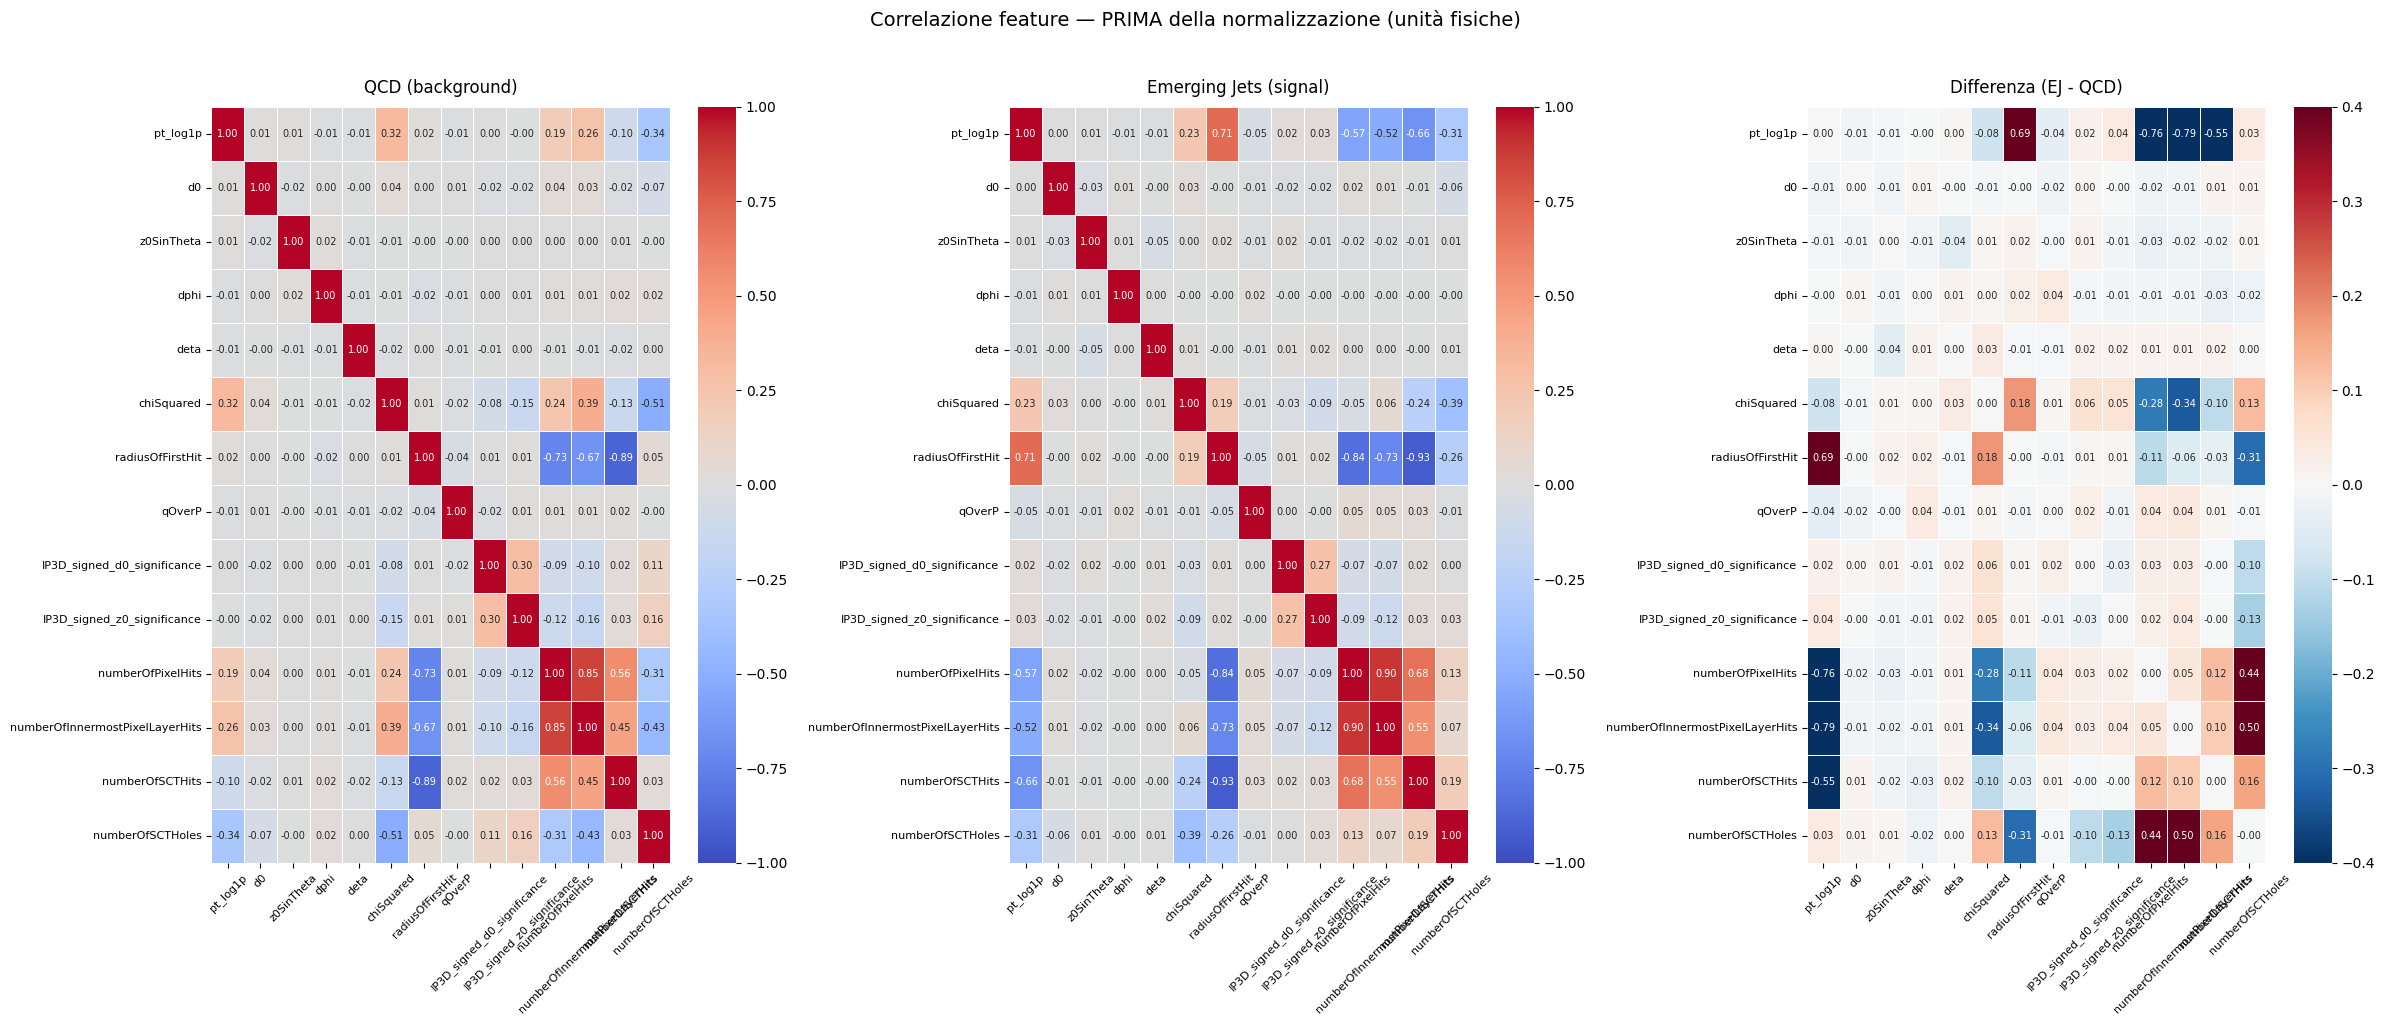

Dopo z-score → X_bkg shape: (50000, 200, 14)  (max |val| ≈ 10.0, atteso ≤ 10)

Matrice di correlazione DOPO la normalizzazione (verifica):
  Plot salvato in: C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\ej_anomaly\plots\corr_after_norm.png


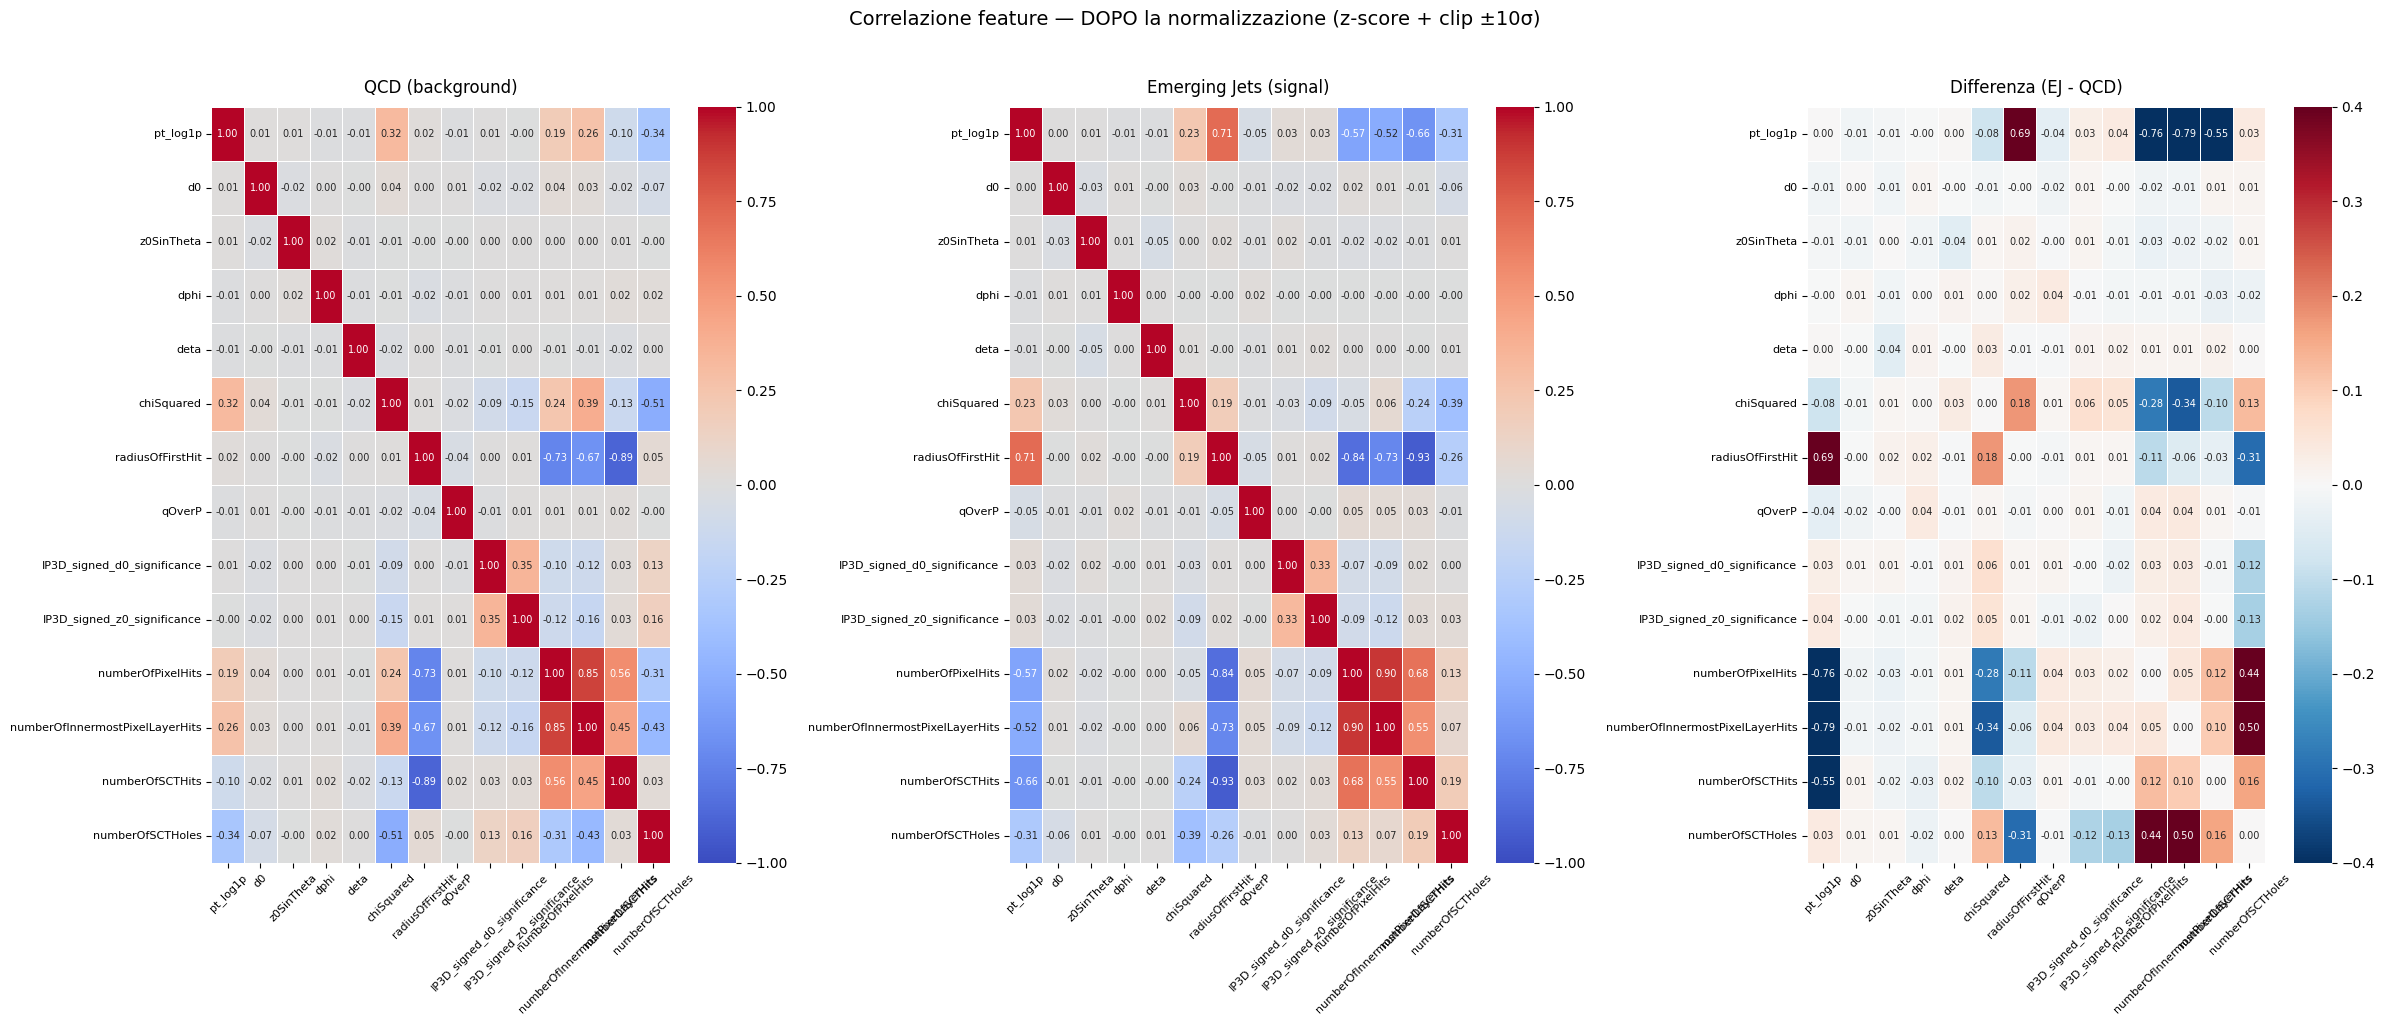


Rappresentazione : aggregate
  X_bkg shape    : (50000, 43)
  X_sig shape    : (61966, 43)
  INPUT_DIM      : 43


In [4]:
# ════════════════════════════════════════════════════════════════════════════
# 2. Caricamento dati e preprocessing ISPEZIONABILE
# ════════════════════════════════════════════════════════════════════════════
# Invece della funzione preprocess() tutto-in-uno, qui spezziamo il preprocessing
# nei suoi passi (load → clean → normalise) così possiamo guardare le correlazioni
# PRIMA e DOPO la normalizzazione e capire cosa succede ai dati.
#
# Ricorda (dal modulo Utils_NEW):
#   - clean_tracks()     : sostituisce NaN/Inf con la media dei supervisori
#   - zscore_normalise() : applica mean/std dei supervisori + clip a ±10σ
#   - le mean/std vengono dal norm_dict.yaml FORNITO dai supervisori

print('Caricamento background (QCD)...')
# load_tracks restituisce un dict {feature: (N, 200)} + la maschera 'valid'
tracks_bkg = load_tracks(BKG_FILE, n_max=N_BKG_TRAIN)
mask_bkg   = tracks_bkg['valid'].astype(bool)
print(f'  Jet caricati : {mask_bkg.shape[0]:,}')
print(f'  Padding medio: {(~mask_bkg).mean()*100:.1f}% degli slot')

print('\nCaricamento segnale (Emerging Jets)...')
# Il segnale lo carichiamo tutto (è piccolo). NON entra mai nel training,
# serve solo per la valutazione finale (ROC).
tracks_sig = load_tracks(SIG_FILE)
mask_sig   = tracks_sig['valid'].astype(bool)
print(f'  Jet segnale  : {mask_sig.shape[0]:,}')

# ── STEP 1: clean (NaN/Inf → media), ancora in unità fisiche ──────────────────
X_bkg_clean, mask_bkg = clean_tracks(tracks_bkg, mask_bkg)
X_sig_clean, mask_sig = clean_tracks(tracks_sig, mask_sig)
print(f'\nDopo clean → X_bkg shape: {X_bkg_clean.shape}  (jet × tracce × feature)')

# ── Matrice di correlazione PRIMA della normalizzazione ───────────────────────
# Qui le feature sono in unità fisiche: le correlazioni sono quelle "vere".
# Confrontiamo QCD vs EJ: le coppie che cambiano molto tra i due sono
# potenzialmente discriminanti.
print('\nMatrice di correlazione PRIMA della normalizzazione (QCD vs EJ):')
plot_correlation_matrix(
    X_bkg_clean, mask_bkg,
    X_sig=X_sig_clean, mask_sig=mask_sig,
    title='Correlazione feature — PRIMA della normalizzazione (unità fisiche)',
    save_path=os.path.join(PLOTS_DIR, 'corr_before_norm.png'),
)

# ── STEP 2: z-score + clip a ±10σ (usando mean/std dei supervisori) ────────────
X_bkg_norm = zscore_normalise(X_bkg_clean, mask_bkg)
X_sig_norm = zscore_normalise(X_sig_clean, mask_sig)
print(f'Dopo z-score → X_bkg shape: {X_bkg_norm.shape}  (max |val| ≈ {np.abs(X_bkg_norm).max():.1f}, atteso ≤ 10)')

# ── Matrice di correlazione DOPO la normalizzazione ───────────────────────────
# La z-score è una trasformazione lineare per-feature: NON cambia le correlazioni
# di Pearson (sono invarianti per scalatura/traslazione). Quindi questa matrice
# dovrebbe essere quasi identica a quella di prima — è una VERIFICA che la
# normalizzazione non abbia introdotto artefatti. (Il clip a ±10σ può cambiarle
# di pochissimo, perché tocca solo gli outlier estremi.)
print('\nMatrice di correlazione DOPO la normalizzazione (verifica):')
plot_correlation_matrix(
    X_bkg_norm, mask_bkg,
    X_sig=X_sig_norm, mask_sig=mask_sig,
    title='Correlazione feature — DOPO la normalizzazione (z-score + clip ±10σ)',
    save_path=os.path.join(PLOTS_DIR, 'corr_after_norm.png'),
)

# ── STEP 3: costruzione della rappresentazione per il modello ─────────────────
if REPR == 'aggregate':
    X_bkg = make_aggregate_embeddings(X_bkg_norm, mask_bkg)
    X_sig = make_aggregate_embeddings(X_sig_norm, mask_sig)
    INPUT_DIM = X_bkg.shape[1]   # 43 = 14*3 + 1
elif REPR == 'pt_sorted':
    Xb, mask_bkg = sort_by_pt(X_bkg_norm, mask_bkg)
    Xs, mask_sig = sort_by_pt(X_sig_norm, mask_sig)
    X_bkg = Xb.reshape(len(Xb), -1)
    X_sig = Xs.reshape(len(Xs), -1)
    INPUT_DIM = X_bkg.shape[1]   # 2800 = 200*14
elif REPR == 'd0_sorted':
    Xb, mask_bkg = sort_by_d0(X_bkg_norm, mask_bkg)
    Xs, mask_sig = sort_by_d0(X_sig_norm, mask_sig)
    X_bkg = Xb.reshape(len(Xb), -1)
    X_sig = Xs.reshape(len(Xs), -1)
    INPUT_DIM = X_bkg.shape[1]
else:
    raise ValueError(f'REPR non riconosciuta: {REPR}')

print(f'\nRappresentazione : {REPR}')
print(f'  X_bkg shape    : {X_bkg.shape}')
print(f'  X_sig shape    : {X_sig.shape}')
print(f'  INPUT_DIM      : {INPUT_DIM}')

Il terzo pannello (EJ − QCD) è quello interessante — ti dice dove il segnale si comporta diversamente dal fondo:

- `radiusOfFirstHit` ↔ `pt_log1p`: +0.70 di differenza. Negli EJ il raggio del primo hit si correla molto di più col pT di quanto faccia nel QCD. Questo è proprio l'effetto displaced: le tracce EJ hanno una relazione raggio-impulso diversa.
- `pt_log1p` ↔ `hit counts`: −0.76, −0.78, −0.56. Forte cambiamento di segno/intensità. Negli EJ il legame tra impulso e numero di hit è ribaltato rispetto al QCD.
- `numberOfSCTHoles` ↔ `pixel hits`: +0.42, +0.49. Coerente: tracce displaced saltano layer (più buchi) e hanno meno hit interni.

Questo terzo pannello è materiale da relazione: dimostra quantitativamente che la firma EJ vive nelle correlazioni tra feature di tracking, non nelle singole feature. Ottimo da citare.

---
## 3. Dataset e DataLoader

PyTorch lavora con **tensori** e con il concetto di **DataLoader**:
- Un `TensorDataset` è semplicemente un wrapper attorno ai nostri array numpy
- Un `DataLoader` spezza il dataset in **batch** e li shuffla ad ogni epoca

Dividiamo il background in **train** (90%) e **validation** (10%).
La validation serve per monitorare se il modello sta overfittando:
se la loss di training scende ma quella di validation sale, il modello
sta memorizzando i dati invece di imparare caratteristiche generali.

### Cosa sono i batch?
Immagina di dover insegnare a qualcuno la differenza tra gatti e cani mostrandogli 100.000 foto. Hai due strategie:

- Mostrargli tutte le 100.000 foto, poi dirgli "aggiorna la tua idea di cosa è un gatto"
- Mostrargli 1.000 foto alla volta, aggiornarsi, poi le prossime 1.000, e così via

La seconda è molto più efficiente — impara più velocemente e non deve tenere in testa tutto in una volta.
Un **batch** è esattamente questo: un **sottoinsieme dei dati su cui la rete calcola l'errore e aggiorna i pesi**. Con BATCH_SIZE = 1024 la rete vede 1024 jet, calcola quanto ha sbagliato su quei 1024, aggiorna i pesi, poi passa ai prossimi 1024.

Questo aggiornamento ripetuto si chiama **gradient descent** — ad ogni batch la rete fa un piccolo passo nella direzione che riduce l'errore.
Con 90.000 jet di training e batch da 1024 hai ~88 aggiornamenti per epoca. Con 50 epoche la rete aggiorna i pesi ~4.400 volte in totale.

In [5]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. Split dei dati: train / val / test (SOLO QCD) + segnale a parte
# ══════════════════════════════════════════════════════════════════════════════
#
# SCHEMA DEI DATI (metodologia iron-clad):
#
#   QCD (background)                        SEGNALE (Emerging Jets)
#      ├─ TRAIN (70%) → allena i modelli        │  MAI toccato durante il tuning
#      ├─ VAL   (15%) → tuning iperparametri    │  entra SOLO nella valutazione
#      └─ TEST  (15%) → valutazione finale ─────┴──→ ultima cella
#
# Questo elimina ogni forma di data leakage: il segnale non viene mai
# osservato mentre si esplora lo spazio degli iperparametri.

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15
TEST_FRAC  = 0.15   # = 1 - TRAIN_FRAC - VAL_FRAC

# Permutazione riproducibile degli indici
rng_split = np.random.default_rng(SEED)
perm      = rng_split.permutation(len(X_bkg))

n_total = len(X_bkg)
n_tr    = int(n_total * TRAIN_FRAC)
n_vl    = int(n_total * VAL_FRAC)

idx_train = perm[:n_tr]
idx_val   = perm[n_tr : n_tr + n_vl]
idx_test  = perm[n_tr + n_vl :]

X_bkg_train = X_bkg[idx_train]   # allena
X_bkg_val   = X_bkg[idx_val]     # tuning (val-loss QCD)
X_bkg_test  = X_bkg[idx_test]    # valutazione finale (mai toccato nel tuning)

print('Split QCD (background):')
print(f'  TRAIN : {len(X_bkg_train):,} jet  ({TRAIN_FRAC:.0%})')
print(f'  VAL   : {len(X_bkg_val):,} jet  ({VAL_FRAC:.0%})  → tuning')
print(f'  TEST  : {len(X_bkg_test):,} jet  ({TEST_FRAC:.0%})  → valutazione finale')
print(f'  Segnale: {len(X_sig):,} jet  → valutazione finale (mai toccato nel tuning)')

# Tensori e DataLoader per train e val
# (il test resta numpy: serve solo alla valutazione finale)
X_train_t = torch.tensor(X_bkg_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_bkg_val,   dtype=torch.float32)

train_ds = TensorDataset(X_train_t)
val_ds   = TensorDataset(X_val_t)

n_train = len(train_ds)
n_val   = len(val_ds)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f'\nBatch per epoca (train): {n_train // BATCH_SIZE}')

Split QCD (background):
  TRAIN : 35,000 jet  (70%)
  VAL   : 7,500 jet  (15%)  → tuning
  TEST  : 7,500 jet  (15%)  → valutazione finale
  Segnale: 61,966 jet  → valutazione finale (mai toccato nel tuning)

Batch per epoca (train): 34


---
## 4. Modello Autoencoder

L'architettura è un **MLP simmetrico**:

```
INPUT (43)  →  [128]  →  [64]  →  LATENT (16)  →  [64]  →  [128]  →  OUTPUT (43)
              encoder                              decoder
```

Ogni strato nascosto usa:
- **Linear**: trasformazione lineare `y = Wx + b`
- **BatchNorm**: normalizza l'output di ogni strato → training più stabile
- **ReLU**: non-linearità → senza di essa l'intera rete sarebbe equivalente a una sola trasformazione lineare
- **Dropout**: azzera casualmente una frazione dei neuroni → regolarizzazione

L'ultimo strato del decoder **non** ha attivazione (output lineare),
perché i nostri dati normalizzati possono essere negativi.

In [6]:
class Autoencoder(nn.Module):
    """
    Autoencoder MLP simmetrico.
    
    Parametri
    ---------
    input_dim   : dimensione del vettore di input (es. 43 per aggregate)
    latent_dim  : dimensione dello spazio latente (il collo di bottiglia)
    hidden_dims : lista delle dimensioni degli strati nascosti dell'encoder
                  il decoder è il simmetrico
    dropout     : probabilità di dropout
    """
    def __init__(self, input_dim, latent_dim, hidden_dims, dropout=0.1):
        super().__init__()

        # ── Costruzione dell'encoder ──────────────────────────────────────────
        # Partiamo da input_dim e scendiamo progressivamente fino a latent_dim
        encoder_layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            encoder_layers += [
                nn.Linear(prev_dim, h_dim),   # trasformazione lineare
                nn.BatchNorm1d(h_dim),        # normalizzazione per batch
                nn.ReLU(),                    # non-linearità
                nn.Dropout(dropout),          # regolarizzazione
            ]
            prev_dim = h_dim
        # Strato finale dell'encoder: scende fino allo spazio latente
        encoder_layers.append(nn.Linear(prev_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        # ── Costruzione del decoder ───────────────────────────────────────────
        # Speculare all'encoder: parte da latent_dim e risale fino a input_dim
        decoder_layers = []
        prev_dim = latent_dim
        for h_dim in reversed(hidden_dims):  # reversed: 64→128 invece di 128→64
            decoder_layers += [
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            prev_dim = h_dim
        # Strato finale del decoder: nessuna attivazione (output lineare)
        decoder_layers.append(nn.Linear(prev_dim, input_dim))
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x):
        """Proietta l'input nello spazio latente."""
        return self.encoder(x)

    def decode(self, z):
        """Ricostruisce l'input a partire dal codice latente."""
        return self.decoder(z)

    def forward(self, x):
        """Passaggio completo: encode → decode. Restituisce la ricostruzione x_hat."""
        z    = self.encode(x)
        x_hat = self.decode(z)
        return x_hat


# ── Instanzia il modello e spostalo sul device (GPU/CPU) ──────────────────────
model = Autoencoder(
    input_dim   = INPUT_DIM,
    latent_dim  = LATENT_DIM,
    hidden_dims = HIDDEN_DIMS,
    dropout     = DROPOUT,
).to(DEVICE)

# ── Stampa l'architettura e il numero di parametri ────────────────────────────
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f'\nParametri totali: {n_params:,}')


Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=43, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.0, inplace=False)
    (8): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.0, inplace=False)
    (4): Linear(in_features=64, out_features=128, bias=True)
    (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.0, inplace=False)
    (8): Linear(in_features=128, out_features=43, bi

---
## 5. Training

Il training loop segue sempre la stessa struttura in PyTorch:

```
per ogni epoca:
    per ogni batch:
        1. forward pass  → calcola x_hat
        2. calcola loss  → MSE(x, x_hat)
        3. backward pass → calcola i gradienti
        4. optimizer step → aggiorna i pesi
```

**Loss function**: MSE (Mean Squared Error) = media di `(x_i - x̂_i)²` su tutte le feature.
È la scelta naturale per un AE: vogliamo che la ricostruzione sia il più vicina possibile all'input (misura quanto è sbagliata la ricostruzione). Se la ricostruzione è perfetta MSE = 0, più è sbagliata più MSE è grande. 

**Ottimizzatore**: Adam — aggiorna i pesi in modo adattivo (learning rate diverso per ogni parametro). Adam è l'algoritmo che aggiorna i pesi della rete dopo ogni batch.

**scheduler = ReduceLROnPlateau(...)**:
Monitora la val loss e dimezza il learning rate se non migliora per 5 epoche consecutive. Serve perché nelle fasi finali del training passi grandi possono far oscillare la loss invece di convergere — passi più piccoli aiutano a trovare il minimo.

**Early stopping**: se la validation loss non migliora per `PATIENCE` epoche di fila,
interrompiamo il training e ricarichiamo il miglior modello salvato.

## **che differenza c'è tra training e validation?**

Immagina di dover dare un esame. Hai il libro di testo con gli esercizi svolti e poi c'è l'esame vero con esercizi nuovi.

- **Training set** = gli esercizi del libro che studi. La rete li vede, sbaglia, corregge i pesi, li rivede, migliora. Ripetutamente. È normale che alla fine li risolva quasi perfettamente — li ha visti decine di volte.

- **Validation set** = l'esame vero con esercizi nuovi. La rete non li ha mai visti durante lo studio. Se va bene anche qui, significa che ha capito davvero come si fa — non ha solo memorizzato gli esercizi del libro.

Nel codice la differenza è concreta: (Training — i pesi della rete vengono aggiornati) vs (Validation — i pesi non vengono toccati)

- train loss → "quanto bene ricostruisce jet che ha già studiato"
- val loss → "quanto bene ricostruisce jet nuovi mai visti"

In [8]:
# ── Loss e ottimizzatore ──────────────────────────────────────────────────────
# MSELoss: calcola la media di (x - x_hat)^2 su tutti gli elementi
criterion = nn.MSELoss()

# Adam: ottimizzatore adattivo, lr=learning rate iniziale
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# ReduceLROnPlateau: dimezza il learning rate se la val_loss non migliora per 5 epoche
# Aiuta il modello a convergere meglio nelle fasi finali del training
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ── Early stopping ────────────────────────────────────────────────────────────---------------------------------------------------------------
PATIENCE        = 10    # epoche di attesa prima di stoppare (es. aspetta PATIENCE=10 epoche consecutive senza miglioramento prima di fermarti.)
best_val_loss   = float('inf')
epochs_no_improv = 0 #conta quante epoche consecutive la val loss non è migliorata

# Liste per tenere traccia della loss ad ogni epoca (per il plot finale)
train_losses = []
val_losses   = []

print(f'Inizio training per {N_EPOCHS} epoche...')
print(f'{"Epoca":>6}  {"Train Loss":>12}  {"Val Loss":>12}  {"LR":>10}')
print('-' * 50)

## PARTE IL LOOP PRINCIPALE ##
for epoch in range(1, N_EPOCHS + 1):

    # ── TRAINING ─────────────────────────────────────────────────────────────
    model.train()   # attiva dropout e batchnorm in modalità training
    train_loss = 0.0

    for (batch,) in train_loader:
        batch = batch.to(DEVICE)   # sposta il batch sulla GPU

        optimizer.zero_grad()      # azzera i gradienti del passo precedente
        x_hat = model(batch)       # forward pass: calcola la ricostruzione
        loss  = criterion(x_hat, batch)  # MSE tra ricostruzione e input originale
        loss.backward()            # backward pass: calcola i gradienti
        optimizer.step()           # aggiorna i pesi nella direzione del gradiente

        train_loss += loss.item() * len(batch)  # accumula la loss pesata per il batch

    train_loss /= n_train   # media sull'intero training set

    # ── VALIDATION ───────────────────────────────────────────────────────────
    model.eval()   # disattiva dropout (valutazione deterministica) --> Leggi nota markdown sotto
    val_loss = 0.0

    with torch.no_grad():  # dice a PyTorch di non calcolare i gradienti. Durante la validation non stiamo aggiornando i pesi, quindi i gradienti sarebbero solo spreco di memoria e tempo.
        for (batch,) in val_loader:
            batch = batch.to(DEVICE)
            x_hat = model(batch)
            val_loss += criterion(x_hat, batch).item() * len(batch)

    val_loss /= n_val

    # ── Aggiorna scheduler e log ──────────────────────────────────────────────
    scheduler.step(val_loss)
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    if epoch % 5 == 0 or epoch == 1:
        print(f'{epoch:>6}  {train_loss:>12.6f}  {val_loss:>12.6f}  {current_lr:>10.2e}')

    # ── Early stopping ────────────────────────────────────────────────────────
    if val_loss < best_val_loss: # Se la val loss è migliorata — salva il modello su disco
        best_val_loss    = val_loss
        epochs_no_improv = 0
        torch.save(model.state_dict(), SAVE_PATH)  # salva il miglior modello
    else:
        epochs_no_improv += 1
        if epochs_no_improv >= PATIENCE:
            print(f'\nEarly stopping a epoca {epoch} (no improvement per {PATIENCE} epoche)')
            break

# ── Ricarica il miglior modello ───────────────────────────────────────────────
model.load_state_dict(torch.load(SAVE_PATH, weights_only=True))
print(f'\nBest val loss: {best_val_loss:.6f}')
print(f'Modello salvato in: {SAVE_PATH}')


Inizio training per 50 epoche...
 Epoca    Train Loss      Val Loss          LR
--------------------------------------------------
     1      0.024499      0.022587    1.00e-03
     5      0.021033      0.020419    1.00e-03
    10      0.019145      0.018403    1.00e-03
    15      0.017805      0.017352    1.00e-03
    20      0.017494      0.016118    1.00e-03
    25      0.016827      0.015747    1.00e-03
    30      0.016260      0.015560    1.00e-03
    35      0.015641      0.015195    1.00e-03
    40      0.014921      0.014394    1.00e-03
    45      0.014789      0.014004    1.00e-03
    50      0.014859      0.013641    1.00e-03

Best val loss: 0.013641
Modello salvato in: C:\Users\dfraj\OneDrive\Desktop\Master\Adv_ML\Progetto\ej_anomaly\models\ae_latent16_locale.pt


## NOTA: 
**Deterministica significa che dato lo stesso input, la rete produce sempre lo stesso output.**
Il dropout rompe questa proprietà — azzera neuroni casualmente ad ogni passaggio. Se calcoli la val loss con il dropout attivo, ogni volta che la rete vede lo stesso jet produce un output leggermente diverso perché neuroni diversi vengono azzerati. La val loss cambierebbe ad ogni calcolo anche senza aggiornare i pesi — non sapresti mai se è migliorata davvero o è solo fortuna del dropout.

Con model.eval() il dropout è spento, la rete è stabile, e la val loss è una misura affidabile di quanto il modello sta funzionando

## Perché salviamo in base alla val loss e non alla train loss?

- La **train loss** misura quanto bene la rete ricostruisce i jet che ha **già visto** durante il training. Scende quasi sempre — la rete si adatta ai dati di training per definizione.

- La **val loss** misura quanto bene la rete ricostruisce jet che non ha **mai visto**. È la misura onesta della qualità del modello.


Il problema si chiama **overfitting** — la rete può **imparare a memoria** i dati di training invece di imparare le strutture fisiche sottostanti.


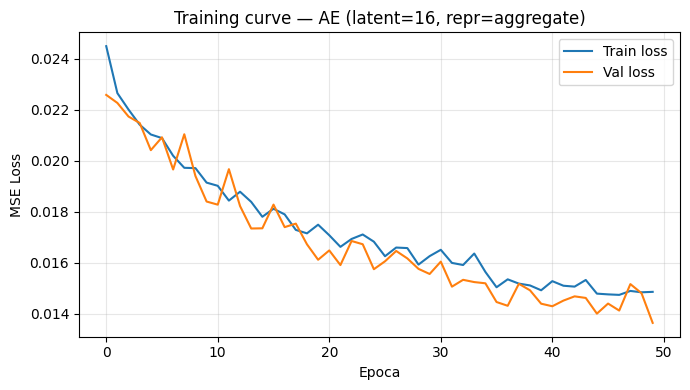

In [9]:
# ── Plot della loss durante il training ───────────────────────────────────────
# Se train loss e val loss scendono insieme → il modello sta imparando bene
# Se val loss risale mentre train loss scende → overfitting
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(train_losses, label='Train loss')
ax.plot(val_losses,   label='Val loss')
ax.set_xlabel('Epoca')
ax.set_ylabel('MSE Loss')
ax.set_title(f'Training curve — AE (latent={LATENT_DIM}, repr={REPR})')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'ae_training_curve.png'), dpi=130, bbox_inches='tight')
plt.show()


---
## 6. Anomaly Score

Questa è la sezione dove il modello addestrato viene finalmente usato per quello che ci interessa: distinguere il segnale dal fondo.

**Concetto base**: Il modello è stato addestrato solo su QCD. Ora gli presentiamo sia jet QCD che Emerging Jets e misuriamo quanto sbaglia la ricostruzione per ciascuno.


L'**anomaly score** è il numero che usiamo per decidere se un jet è anomalo o no.
Per un Autoencoder, la scelta naturale è l'**errore di ricostruzione per jet**:

$$\text{score}(x) = \frac{1}{D} \sum_{i=1}^{D} (x_i - \hat{x}_i)^2 = \text{MSE}(x, \hat{x})$$

dove $D$ è la dimensione dell'input (43 nel caso aggregate).

**Intuizione**: il modello è stato addestrato solo su QCD, quindi:
- Jet QCD → ricostruzione buona → errore **basso**
- Emerging Jet → ricostruzione cattiva → errore **alto**

Calcoliamo lo score su **tutti** i jet di background e segnale.

---
> **Nota metodologica — valutazione su test set**
>
> Il QCD di background e' stato diviso in tre parti (70 / 15 / 15):
> `X_bkg_train` (training), `X_bkg_val` (tuning iperparametri), `X_bkg_test` (valutazione).
>
> Tutte le celle di questa sezione (score, distribuzioni, per-feature MSE) e della sezione 7
> (ROC, SIC) usano **`X_bkg_test`** , ovvero la parte di QCD che il modello non ha mai visto
> ne' durante il training ne' durante il tuning. Il segnale (Emerging Jets) e' sempre
> confrontato con `X_bkg_test`.
>
> In questo modo nessuna cella di valutazione include dati su cui il modello si e'
> allenato, e la stima di AUC / SIC e' onesta.

In [10]:
#Questa funzione prende il modello addestrato e un dataset, e restituisce un numero per ogni jet — il suo anomaly score.
def compute_anomaly_scores(model, X_np, batch_size=4096, device=DEVICE): # Usiamo batch grandi (4096) perché non dobbiamo calcolare gradienti - possiamo permetterci di usare più memoria.
    """
    Calcola l'errore di ricostruzione per-jet su un intero dataset.
    
    Parametri
    ---------
    model      : Autoencoder addestrato
    X_np       : numpy array (N, D) — dataset da valutare
    batch_size : quanti jet per batch (più grande = più veloce, ma più RAM)
    
    Restituisce
    -----------
    scores : numpy array (N,) — MSE per-jet
    """
    model.eval()   # modalità inferenza: dropout disattivato
    scores = []

    X_tensor = torch.tensor(X_np, dtype=torch.float32)
    loader   = DataLoader(TensorDataset(X_tensor), batch_size=batch_size)

    with torch.no_grad():
        for (batch,) in loader:
            batch = batch.to(device)
            x_hat = model(batch)

            # MSE per-jet: mean su tutte le feature (dim=1), non sul batch intero
            # shape: (batch_size,)
            mse_per_jet = ((batch - x_hat) ** 2).mean(dim=1)
            scores.append(mse_per_jet.cpu().numpy()) #riporta il tensore dalla GPU alla RAM e lo converte in numpy per poterlo usare con matplotlib e sklearn.
            #Questo è il punto cruciale — non calcoliamo un singolo MSE per tutto il batch come facevamo nel training. Qui vogliamo un numero per ogni jet individuale.

    return np.concatenate(scores)   # (N,) array


# ── Calcola gli score su background e segnale ─────────────────────────────────
print('Calcolo anomaly scores...')
scores_bkg = compute_anomaly_scores(model, X_bkg_test)
scores_sig = compute_anomaly_scores(model, X_sig)

print(f'Background — mean score: {scores_bkg.mean():.4f} ± {scores_bkg.std():.4f}')
print(f'Segnale    — mean score: {scores_sig.mean():.4f} ± {scores_sig.std():.4f}')
print(f'\nRatio segnale/background: {scores_sig.mean()/scores_bkg.mean():.2f}x')
print('(ratio > 1 indica che il segnale viene ricostruito peggio → buon segno)')


Calcolo anomaly scores...
Background — mean score: 0.0137 ± 0.0065
Segnale    — mean score: 0.0232 ± 0.0121

Ratio segnale/background: 1.69x
(ratio > 1 indica che il segnale viene ricostruito peggio → buon segno)


Se il modello funziona il ratio deve essere maggiore di 1 — il segnale viene ricostruito peggio. Più è alto, meglio è

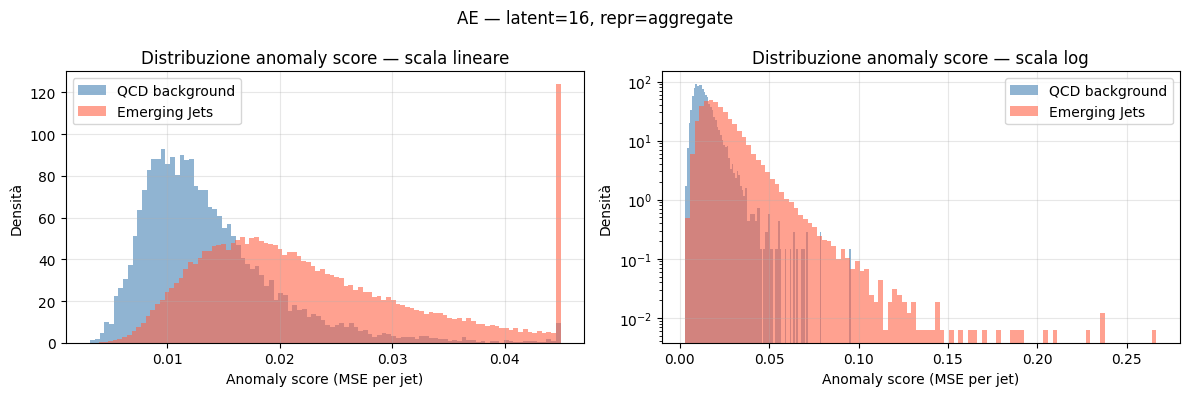

In [11]:
# Alcuni EJ hanno score estremi (~1e12) per via di tracce molto displaced che il modello
# non sa ricostruire per niente. Se li includiamo nel plot lineare, l'asse x va da 0 a 1e12
# e tutte le barre si accumulano invisibili a sinistra. Il clip al 95° percentile del segnale
# rimuove solo il 5% più estremo degli EJ, preservando la forma delle distribuzioni.
# NOTA: il clip è SOLO per la visualizzazione — scores_bkg e scores_sig originali
# rimangono intatti e vengono usati per la ROC (sezione 7).
scores_bkg_plot = np.clip(scores_bkg, 0, np.percentile(scores_sig, 95))
scores_sig_plot = np.clip(scores_sig, 0, np.percentile(scores_sig, 95))
# ────────────────────────────────────────────────────────────────────────────────────────────


# ── Distribuzione degli anomaly score ─────────────────────────────────────────
# Se le due distribuzioni sono separate → il modello distingue bene segnale da fondo
# Se si sovrappongono molto → il modello fa fatica
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scala lineare
ax = axes[0]
ax.hist(scores_bkg_plot, bins=100, density=True, alpha=0.6, label='QCD background', color='steelblue')
ax.hist(scores_sig_plot, bins=100, density=True, alpha=0.6, label='Emerging Jets',  color='tomato')
ax.set_xlabel('Anomaly score (MSE per jet)')
ax.set_ylabel('Densità')
ax.set_title('Distribuzione anomaly score — scala lineare')
ax.legend()
ax.grid(alpha=0.3)

# Scala logaritmica sull'asse y: mostra meglio le code delle distribuzioni
ax = axes[1]
ax.hist(scores_bkg, bins=100, density=True, alpha=0.6, label='QCD background', color='steelblue')
ax.hist(scores_sig, bins=100, density=True, alpha=0.6, label='Emerging Jets',  color='tomato')
ax.set_xlabel('Anomaly score (MSE per jet)')
ax.set_ylabel('Densità')
ax.set_title('Distribuzione anomaly score — scala log')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3)

plt.suptitle(f'AE — latent={LATENT_DIM}, repr={REPR}', fontsize=12)
plt.tight_layout()
os.makedirs(PLOTS_DIR, exist_ok=True)
plt.savefig(os.path.join(PLOTS_DIR, 'ae_score_distributions.png'), dpi=130, bbox_inches='tight')
plt.show()


### Errore di ricostruzione per feature

Quale delle 43 feature viene ricostruita peggio per gli EJ rispetto al QCD?
Il ratio MSE_segnale / MSE_background ci dice quali feature fisiche
guidano l'anomaly score — quelle con ratio alto sono le più discriminanti.

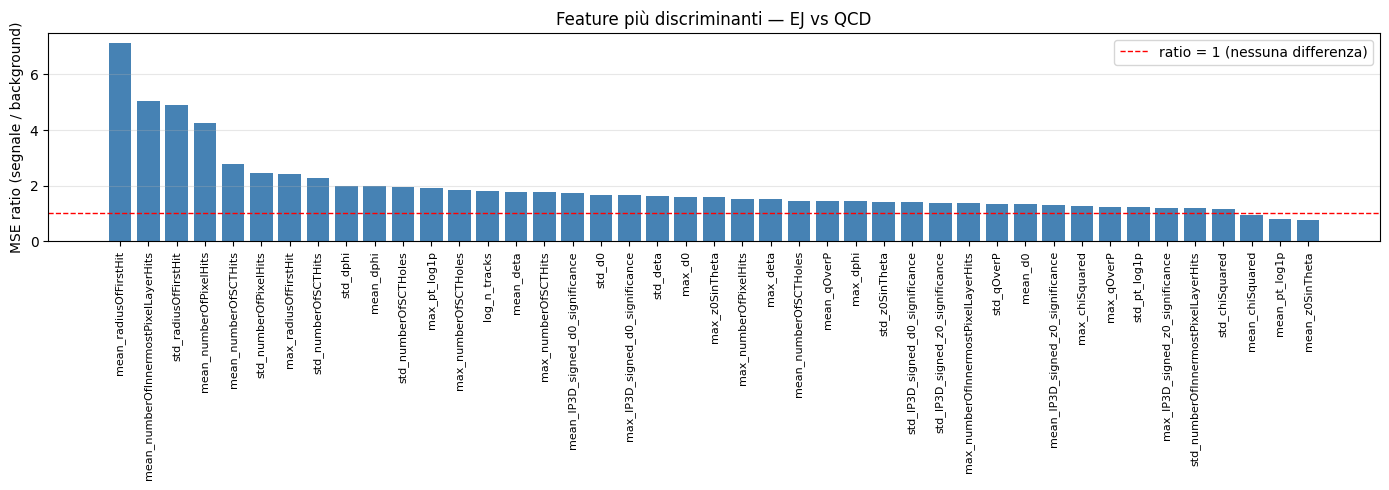

Top 5 feature più discriminanti:
  mean_radiusOfFirstHit                ratio = 7.141
  mean_numberOfInnermostPixelLayerHits  ratio = 5.063
  std_radiusOfFirstHit                 ratio = 4.900
  mean_numberOfPixelHits               ratio = 4.255
  mean_numberOfSCTHits                 ratio = 2.778


In [12]:
def per_feature_mse(model, X_np, device=DEVICE):
    model.eval()
    X_t = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        x_hat = model(X_t.to(device)).cpu()
    return ((X_t - x_hat) ** 2).mean(dim=0).numpy()  # (43,)

feat_mse_bkg = per_feature_mse(model, X_bkg_test)
feat_mse_sig = per_feature_mse(model, X_sig)
ratio = feat_mse_sig / feat_mse_bkg

# Nomi delle 43 feature: mean/max/std per ognuna delle 14 + log(n_tracce)
from src.utils import TRACK_FEATURES
feat_names = (
    [f'mean_{f}' for f in TRACK_FEATURES] +
    [f'max_{f}'  for f in TRACK_FEATURES] +
    [f'std_{f}'  for f in TRACK_FEATURES] +
    ['log_n_tracks']
)

# Ordina per ratio decrescente
order = np.argsort(ratio)[::-1]

fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(ratio)), ratio[order], color='steelblue')
ax.axhline(1.0, color='red', linestyle='--', lw=1, label='ratio = 1 (nessuna differenza)')
ax.set_xticks(range(len(ratio)))
ax.set_xticklabels([feat_names[i] for i in order], rotation=90, fontsize=8)
ax.set_ylabel('MSE ratio (segnale / background)')
ax.set_title('Feature più discriminanti — EJ vs QCD')
ax.legend()
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'ae_per_feature_ratio.png'), dpi=130, bbox_inches='tight')
plt.show()

# Stampa le top 5
print('Top 5 feature più discriminanti:')
for i in order[:5]:
    print(f'  {feat_names[i]:35s}  ratio = {ratio[i]:.3f}')


---
## 7. Valutazione — ROC curve e AUC

La **curva ROC** (Receiver Operating Characteristic) mostra il trade-off tra:
- **TPR** (True Positive Rate): frazione di Emerging Jets identificati correttamente
- **FPR** (False Positive Rate): frazione di jet QCD erroneamente classificati come segnale

L'**AUC** (Area Under the Curve) riassume la performance in un singolo numero:
- AUC = 1.0 → separazione perfetta
- AUC = 0.5 → equivalente a una scelta casuale (il modello non distingue nulla)

In fisica delle particelle si usa spesso anche la **curva di rigetto**:
a parità di efficienza sul segnale (TPR), quanta frazione di background riusciamo a rigettare?

L'AUC (Area Under the Curve) riassume tutta la curva in un numero:


AUC = 1.0 → curva che va subito in alto a sinistra — il modello separa perfettamente segnale da fondo

AUC = 0.5 → curva sulla diagonale — il modello non distingue nulla, equivale a scegliere a caso

AUC = 0.7 → discreto, il modello ha potere discriminante ma non perfetto

Nel nostro caso un AUC di 0.7-0.8 sarebbe già un buon risultato per un modello non supervisionato.

 **AUC = "Area Under the ROC Curve". In pratica misura una cosa sola: se prendi a caso un EJ e un jet QCD, qual è la probabilità che il modello assegni uno score più alto all'EJ?** 

**Nel nostro AE, lo score è semplicemente l'errore di ricostruzione: quanto ha sbagliato la rete nel ricostruire quel jet.**

**Lo score è quindi un numero per ogni jet — "quanto è strano questo jet per il modello". Più è alto, più il modello lo trova anomalo.**

### AUC — definizione intuitiva

  Prendi un EJ a caso e un jet QCD a caso. Guardi i loro score (errori di ricostruzione). AUC = la probabilità che l'EJ
  abbia score più alto del QCD.

  - AUC=0.82 → nell'82% dei casi l'EJ ha errore più alto del QCD → il modello li distingue bene
  - AUC=0.5 → 50% delle volte, quindi puramente casuale — tanto vale tirare una moneta

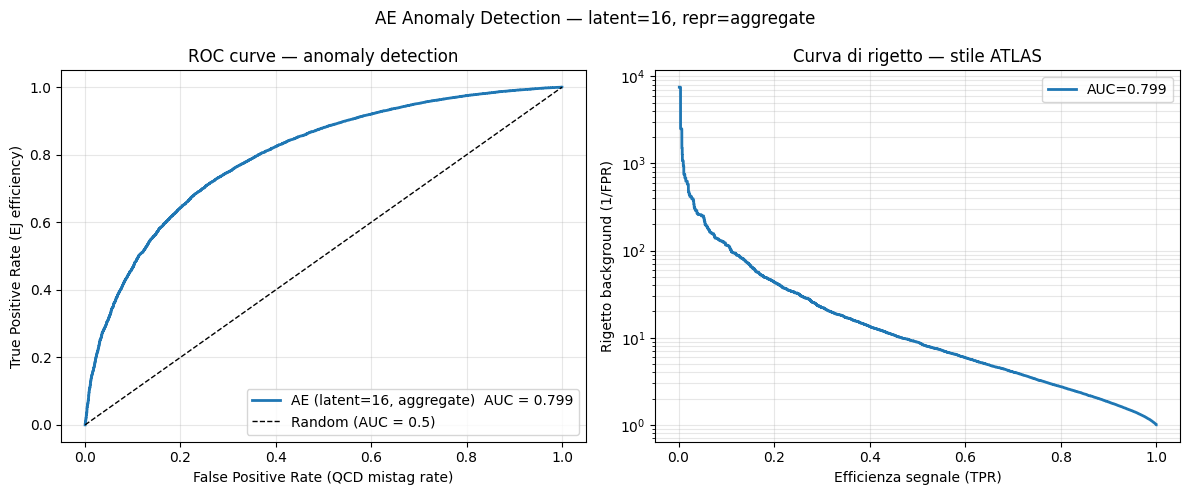

AUC = 0.7988
  Efficienza segnale 30%  →  rigetto background: 22.3x
  Efficienza segnale 50%  →  rigetto background: 8.9x
  Efficienza segnale 70%  →  rigetto background: 4.1x


In [13]:
# ── ROC curve ─────────────────────────────────────────────────────────────────
fpr, tpr, roc_auc = compute_roc(scores_bkg, scores_sig)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ROC standard
ax = axes[0]
plot_roc(fpr, tpr, roc_auc, label=f'AE (latent={LATENT_DIM}, {REPR})', ax=ax)

# Curva di rigetto del background (più comune in ATLAS)
# Asse x: efficienza sul segnale (TPR)
# Asse y: rigetto del background = 1/FPR (scala log)
# Vogliamo rigetto alto a alta efficienza → curva in alto a destra
ax = axes[1]
# Evita divisione per zero nei punti dove FPR=0
mask_nonzero = fpr > 0
ax.plot(tpr[mask_nonzero], 1.0 / fpr[mask_nonzero], lw=2,
        label=f'AUC={roc_auc:.3f}')
ax.set_xlabel('Efficienza segnale (TPR)')
ax.set_ylabel('Rigetto background (1/FPR)')
ax.set_title('Curva di rigetto — stile ATLAS')
ax.set_yscale('log')
ax.legend()
ax.grid(alpha=0.3, which='both')

plt.suptitle(f'AE Anomaly Detection — latent={LATENT_DIM}, repr={REPR}', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'ae_roc.png'), dpi=130, bbox_inches='tight')
plt.show()

print(f'AUC = {roc_auc:.4f}')

# ── Rigetto a efficienza fissata ──────────────────────────────────────────────
# Domanda tipica: "se voglio tenere il 50% degli EJ, quanti QCD rigetto?"
for sig_eff in [0.3, 0.5, 0.7]:
    # Trova il punto della ROC più vicino all'efficienza target
    idx = np.argmin(np.abs(tpr - sig_eff))
    bkg_rej = 1.0 / fpr[idx] if fpr[idx] > 0 else float('inf')
    print(f'  Efficienza segnale {sig_eff*100:.0f}%  →  rigetto background: {bkg_rej:.1f}x')


  ### SIC — Significance Improvement Characteristic

  La **SIC curve** è la metrica standard nei paper di anomaly detection al LHC (ATLAS, CMS).
  Risponde a una domanda diversa rispetto alla ROC:

  > *Di quanto miglioro la significatività statistica del segnale rispetto a non fare nessuna selezione?*

  **Definizione:**

  $$\text{SIC}(\varepsilon_S) = \frac{\varepsilon_S}{\sqrt{\varepsilon_B}}$$

  dove:
  - $\varepsilon_S$ = frazione di EJ che supera la soglia (efficienza segnale = TPR)
  - $\varepsilon_B$ = frazione di QCD che supera la soglia (= FPR)

  **Perché √ε_B?** In statistica, la significatività di un segnale su fondo scala come
  S/√B. Se tieni il 50% del segnale (ε_S=0.5) e butti via il 99% del fondo (ε_B=0.01),
  la tua significatività migliora di 0.5/√0.01 = 5x rispetto a non fare nessun taglio.

  **Come interpretarla:**
  | Valore SIC | Significato |
  |---|---|
  | SIC = 1 | Nessun miglioramento — il taglio non aiuta |
  | SIC = 3 | La significatività statistica triplica |
  | SIC = 5 | Cinque volte più sensibile al segnale |

  La curva mostra il SIC al variare della soglia (asse x = ε_S).
  Il **picco** indica la soglia ottimale — quella che massimizza la sensibilità al segnale.

  **Differenza rispetto all'AUC ROC:**
  - AUC ROC misura la capacità di *ranking* del modello (threshold-independent)
  - SIC misura il *guadagno fisico reale* a una data soglia operativa
  - Nei paper HEP si riporta quasi sempre SIC_max insieme all'AUC

  ---

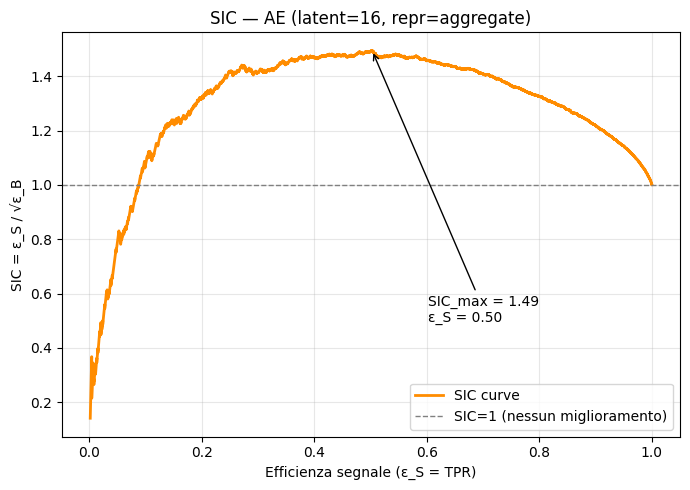

SIC massima : 1.494
Soglia ottimale : ε_S = 0.50  (tieni 50% degli EJ, rigetti 88.7% del QCD)
Interpretazione : a quella soglia la significatività migliora di 1.5x


In [14]:
mask = fpr > 0
sic  = tpr[mask] / np.sqrt(fpr[mask])

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(tpr[mask], sic, lw=2, color='darkorange', label='SIC curve')
ax.axhline(1.0, color='gray', linestyle='--', lw=1, label='SIC=1 (nessun miglioramento)')
ax.set_xlabel('Efficienza segnale (ε_S = TPR)')
ax.set_ylabel('SIC = ε_S / √ε_B')
ax.set_title(f'SIC — AE (latent={LATENT_DIM}, repr={REPR})')
ax.legend()
ax.grid(alpha=0.3)

sic_max    = sic.max()
tpr_at_max = tpr[mask][np.argmax(sic)]
ax.annotate(
    f'SIC_max = {sic_max:.2f}\nε_S = {tpr_at_max:.2f}',
    xy=(tpr_at_max, sic_max),
    xytext=(min(tpr_at_max + 0.1, 0.75), sic_max - 1.0),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10,
)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'ae_sic.png'), dpi=130, bbox_inches='tight')
plt.show()

print(f'SIC massima : {sic_max:.3f}')
print(f'Soglia ottimale : ε_S = {tpr_at_max:.2f}  '
      f'(tieni {tpr_at_max*100:.0f}% degli EJ, rigetti {(1-fpr[mask][np.argmax(sic)])*100:.1f}% del QCD)')
print(f'Interpretazione : a quella soglia la significatività migliora di {sic_max:.1f}x')


_____________________________________________________________________________________________________________________________________________
Nella prossima sezione rispondiamo a una domanda pratica: gli iperparametri che abbiamo scelto nella Sezione 1 sono davvero i migliori?

## 8. Tuning sistematico — metodologia

La consegna chiede esplicitamente il *tuning di latent dimension, regolarizzazione
e input encoding*, e specifica che il modello va addestrato su **dati QCD-only**.

**Principio metodologico (importante).**
In anomaly detection non supervisionata il segnale (Emerging Jets) rappresenta
"ciò che il modello non ha mai visto". Di conseguenza il segnale **non deve
entrare nelle scelte di costruzione del modello** — incluso il tuning degli
iperparametri. Usare l'AUC (che richiede il segnale) come criterio di selezione
significherebbe ottimizzare il modello guardando proprio i dati che dovrebbero
restare nascosti: una forma implicita di supervisione, da evitare.

**Criterio di selezione adottato.**
Selezioniamo gli iperparametri in base alla **loss di ricostruzione su un set di
validazione QCD indipendente** (QCD che il modello non vede durante il training).
Questo misura la capacità del modello di generalizzare sul *background*, ed è
coerente con il vincolo "QCD-only" della consegna.

Sottigliezza specifica degli autoencoder: una latent dimension più grande
riduce sempre la val-loss (più capacità → ricostruzione migliore), ma un AE
con troppa capacità ricostruisce bene *anche* il segnale, degradando il potere
di anomaly detection. Per questo non scegliamo la "val-loss minima assoluta",
ma il punto di **diminishing returns** (il "gomito"): la latent dimension oltre
la quale aggiungere capacità non migliora più sensibilmente la generalizzazione
sul QCD. È il modello più semplice che descrive bene il background (rasoio di Occam).

**Ruolo dell'AUC.**
L'AUC viene comunque calcolata e mostrata in ogni esperimento, ma **solo come
metrica osservata a posteriori** — non come criterio di scelta. La selezione
guarda la val-loss QCD; l'AUC ci dice, dopo, quanto la configurazione scelta
separa effettivamente segnale e fondo.


In [15]:
# Funzione di tuning: addestra un AE con la configurazione data e restituisce
# SOLO la val-loss sul QCD di validazione. NON vede il segnale, NON calcola AUC.
# Questo garantisce che durante il tuning il segnale non venga mai osservato
# (nessun data leakage, nemmeno implicito).

def train_for_tuning(input_dim, latent_dim, hidden_dims, dropout,
                     train_loader, val_loader, n_val,
                     n_epochs=30, lr=1e-3, patience=7, device=DEVICE):
    """
    Addestra un AE (solo QCD) e restituisce la miglior val-loss QCD.
    Unico numero usato per il tuning — il segnale non viene mai toccato.
    """
    model = Autoencoder(input_dim, latent_dim, hidden_dims, dropout).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    best_val, no_improv = float('inf'), 0
    for epoch in range(1, n_epochs + 1):
        model.train()
        for (batch,) in train_loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch), batch)
            loss.backward()
            optimizer.step()

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for (batch,) in val_loader:
                batch = batch.to(device)
                val_loss += criterion(model(batch), batch).item() * len(batch)
        val_loss /= n_val
        scheduler.step(val_loss)

        if val_loss < best_val:
            best_val, no_improv = val_loss, 0
        else:
            no_improv += 1
            if no_improv >= patience:
                break

    return best_val   # SOLO val-loss QCD. Nessun segnale, nessuna AUC.

In [16]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Esperimento 1 — Latent dimension. Criterio: val-loss QCD (gomito).
# Il segnale NON viene toccato.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print('Esperimento 1: latent dimension  (criterio: val-loss QCD)')
print('=' * 45)
print(f"{'latent':>8} | {'val-loss QCD':>14}")
print('-' * 45)

latent_results = {}
for ld in [2, 4, 8, 16, 32]:
    vloss = train_for_tuning(
        input_dim=INPUT_DIM, latent_dim=ld,
        hidden_dims=HIDDEN_DIMS, dropout=DROPOUT,
        train_loader=train_loader, val_loader=val_loader, n_val=n_val,
    )
    latent_results[ld] = vloss
    print(f'{ld:>8} | {vloss:>14.6f}')

Esperimento 1: latent dimension  (criterio: val-loss QCD)
  latent |   val-loss QCD
---------------------------------------------
       2 |       0.182305
       4 |       0.092134
       8 |       0.043870
      16 |       0.020409
      32 |       0.017419


### ⚠️ Nota sull'architettura per rappresentazioni sequenziali

Quando usiamo `pt_sorted` o `d0_sorted`, l'input passa da 43 a 2800 feature
(200 tracce × 14 feature, appiattite in un vettore flat).

Usare gli stessi `HIDDEN_DIMS = [128, 64]` pensati per 43 feature sarebbe
scorretto: il primo layer comprimerebbe brutalmente da 2800 → 128,
buttando via quasi tutta l'informazione prima ancora del collo di bottiglia.

Per questo esperimento usiamo `hidden_dims = [512, 256, 128]` per le
rappresentazioni sequenziali, in modo che la compressione sia graduale:

aggregate : input(43)   → 128 → 64  → z(8) → 64  → 128  → output(43)

pt/d0     : input(2800) → 512 → 256 → 128 → z(8) → 128 → 256 → 512 → output(2800)

**Limitazione importante**: un MLP tratta il vettore da 2800 come una lista
piatta di numeri — non sa che sono raggruppati in blocchi da 14 che
rappresentano tracce. Perde la struttura sequenziale.
Se `d0_sorted` desse AUC basso, non significherebbe necessariamente che
quella rappresentazione è peggiore — potrebbe significare che un MLP flat
non è lo strumento giusto per sfruttarla. Per farlo correttamente
servirebbero RNN, Transformer, o un VAE sequenziale.

In [17]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Esperimento 2 — Input encoding. Criterio: val-loss QCD.
# NOTA: confronto non perfettamente equo (dim input diverse: 43 vs 2800).
# L'encoding si motiva anche su base architetturale, non solo numerica.
# Usiamo idx_train/idx_val direttamente: split coerente con Exp 1 e 3.
# Il segnale NON viene toccato.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print('Esperimento 2: input encoding  (criterio: val-loss QCD)')
print('=' * 45)
print(f"{'encoding':>12} | {'val-loss QCD':>14}")
print('-' * 45)

repr_results = {}
for repr_name in ['aggregate', 'pt_sorted', 'd0_sorted']:
    if repr_name == 'aggregate':
        Xb_tr = make_aggregate_embeddings(X_bkg_norm[idx_train], mask_bkg[idx_train])
        Xb_vl = make_aggregate_embeddings(X_bkg_norm[idx_val],   mask_bkg[idx_val])
        hdims = HIDDEN_DIMS
    elif repr_name == 'pt_sorted':
        Xs_tr, _ = sort_by_pt(X_bkg_norm[idx_train], mask_bkg[idx_train])
        Xs_vl, _ = sort_by_pt(X_bkg_norm[idx_val],   mask_bkg[idx_val])
        Xb_tr = Xs_tr.reshape(len(Xs_tr), -1)
        Xb_vl = Xs_vl.reshape(len(Xs_vl), -1)
        hdims = [512, 256, 128]
    else:
        Xs_tr, _ = sort_by_d0(X_bkg_norm[idx_train], mask_bkg[idx_train])
        Xs_vl, _ = sort_by_d0(X_bkg_norm[idx_val],   mask_bkg[idx_val])
        Xb_tr = Xs_tr.reshape(len(Xs_tr), -1)
        Xb_vl = Xs_vl.reshape(len(Xs_vl), -1)
        hdims = [512, 256, 128]

    tr_t  = torch.tensor(Xb_tr, dtype=torch.float32)
    vl_t  = torch.tensor(Xb_vl, dtype=torch.float32)
    tr_ld = DataLoader(TensorDataset(tr_t), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
    vl_ld = DataLoader(TensorDataset(vl_t), batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    vloss = train_for_tuning(
        input_dim=Xb_tr.shape[1], latent_dim=LATENT_DIM,
        hidden_dims=hdims, dropout=DROPOUT,
        train_loader=tr_ld, val_loader=vl_ld, n_val=len(vl_t),
    )
    repr_results[repr_name] = vloss
    print(f'{repr_name:>12} | {vloss:>14.6f}')

Esperimento 2: input encoding  (criterio: val-loss QCD)
    encoding |   val-loss QCD
---------------------------------------------
   aggregate |       0.020640
   pt_sorted |       0.260247
   d0_sorted |       0.230746


In [18]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Esperimento 3 — Dropout (regolarizzazione). Criterio: val-loss QCD.
# Atteso: la val-loss cresce col dropout (aumenta il rumore nel training).
# Il segnale NON viene toccato.
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

print('Esperimento 3: dropout  (criterio: val-loss QCD)')
print('=' * 45)
print(f"{'dropout':>8} | {'val-loss QCD':>14}")
print('-' * 45)

dropout_results = {}
for dp in [0.0, 0.05, 0.1, 0.2, 0.3]:
    vloss = train_for_tuning(
        input_dim=INPUT_DIM, latent_dim=LATENT_DIM,
        hidden_dims=HIDDEN_DIMS, dropout=dp,
        train_loader=train_loader, val_loader=val_loader, n_val=n_val,
    )
    dropout_results[dp] = vloss
    print(f'{dp:>8.2f} | {vloss:>14.6f}')

Esperimento 3: dropout  (criterio: val-loss QCD)
 dropout |   val-loss QCD
---------------------------------------------
    0.00 |       0.021145
    0.05 |       0.027670
    0.10 |       0.035822
    0.20 |       0.054436
    0.30 |       0.080644


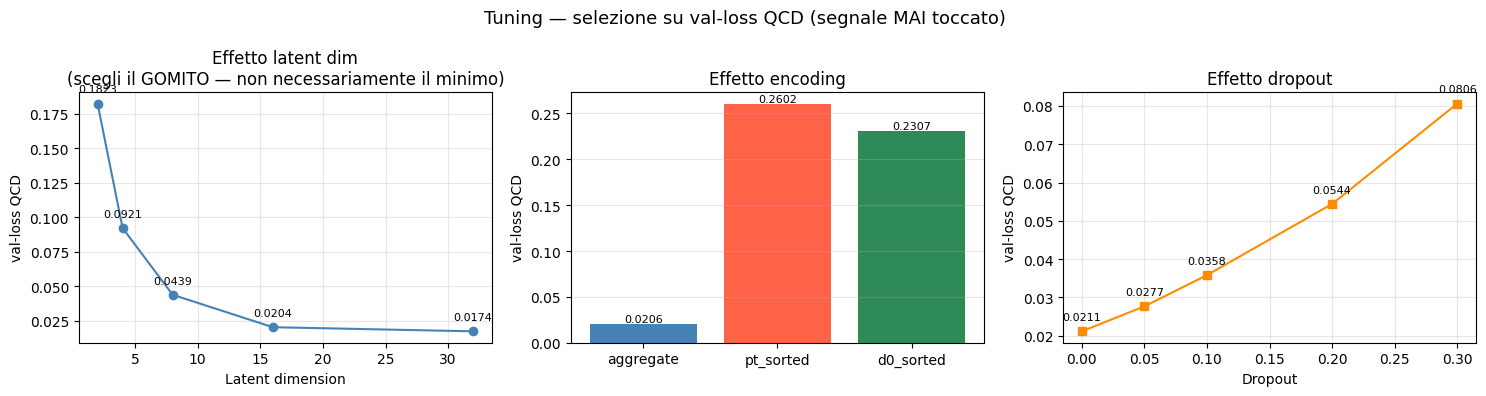


SELEZIONE (criterio: val-loss QCD; segnale mai osservato)
  Latent  : min val-loss a 32 — scegli il GOMITO sul plot (Occam)
  Encoding: aggregate
  Dropout : 0.0

Imposta i valori scelti in Sezione 1 (LATENT_DIM, REPR, DROPOUT)
e procedi alla VALUTAZIONE FINALE (cella successiva), che e' la PRIMA
volta in cui si tocca il segnale + il test-QCD.


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ks = list(latent_results.keys()); vs = list(latent_results.values())
ax.plot(ks, vs, 'o-', color='steelblue')
ax.set_xlabel('Latent dimension'); ax.set_ylabel('val-loss QCD')
ax.set_title('Effetto latent dim\n(scegli il GOMITO — non necessariamente il minimo)')
ax.grid(alpha=0.3)
for k, v in zip(ks, vs):
    ax.annotate(f'{v:.4f}', (k, v), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=8)

ax = axes[1]
rk = list(repr_results.keys()); rv = list(repr_results.values())
ax.bar(rk, rv, color=['steelblue', 'tomato', 'seagreen'])
ax.set_ylabel('val-loss QCD'); ax.set_title('Effetto encoding')
ax.grid(alpha=0.3, axis='y')
for i, v in enumerate(rv):
    ax.text(i, v, f'{v:.4f}', ha='center', va='bottom', fontsize=8)

ax = axes[2]
dk = list(dropout_results.keys()); dv = list(dropout_results.values())
ax.plot(dk, dv, 's-', color='darkorange')
ax.set_xlabel('Dropout'); ax.set_ylabel('val-loss QCD')
ax.set_title('Effetto dropout')
ax.grid(alpha=0.3)
for k, v in zip(dk, dv):
    ax.annotate(f'{v:.4f}', (k, v), textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=8)

plt.suptitle('Tuning — selezione su val-loss QCD (segnale MAI toccato)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'ae_tuning_summary.png'), dpi=130, bbox_inches='tight')
plt.show()

# ── Selezione: minima val-loss (con giudizio del gomito sul latent) ───────────
best_latent_min = min(latent_results, key=latent_results.get)
best_repr       = min(repr_results,   key=repr_results.get)
best_drop       = min(dropout_results, key=dropout_results.get)

print('\n' + '=' * 60)
print('SELEZIONE (criterio: val-loss QCD; segnale mai osservato)')
print('=' * 60)
print(f'  Latent  : min val-loss a {best_latent_min} — scegli il GOMITO sul plot (Occam)')
print(f'  Encoding: {best_repr}')
print(f'  Dropout : {best_drop}')
print()
print("Imposta i valori scelti in Sezione 1 (LATENT_DIM, REPR, DROPOUT)")
print("e procedi alla VALUTAZIONE FINALE (cella successiva), che e' la PRIMA")
print("volta in cui si tocca il segnale + il test-QCD.")

# **Sommario Finale + Valutazione :**

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# SOMMARIO FINALE — riepilogo dei risultati (NON ricalcola nulla)
# ══════════════════════════════════════════════════════════════════════════════
# Questa cella NON esegue nuovi calcoli: raccoglie i risultati già ottenuti nelle
# sezioni 6-7 (valutazione su X_bkg_test + segnale) e li presenta in modo ordinato,
# pronto da riportare nella relazione.
#
# Promemoria metodologico:
#   - Iperparametri scelti col tuning su val-loss QCD (segnale mai usato per scegliere)
#   - AUC/SIC valutate su X_bkg_test (QCD mai visto in training) + segnale completo

print('=' * 60)
print('  SOMMARIO FINALE — AE Anomaly Detection (Emerging Jets)')
print('=' * 60)
print()
print('  CONFIGURAZIONE (selezionata col tuning su val-loss QCD)')
print(f'    Input encoding   : {REPR}')
print(f'    Latent dimension : {LATENT_DIM}')
print(f'    Dropout          : {DROPOUT}')
print(f'    Hidden dims      : {HIDDEN_DIMS}')
print()
print('  DATI')
print(f'    QCD train / val / test : {len(X_bkg_train):,} / {len(X_bkg_val):,} / {len(X_bkg_test):,}')
print(f'    Segnale (EJ)           : {len(X_sig):,}')
print()
print('  PERFORMANCE (su X_bkg_test + segnale, mai visti in training)')
print(f'    AUC                    : {roc_auc:.4f}')
print(f'    Anomaly score QCD      : {scores_bkg.mean():.4f} ± {scores_bkg.std():.4f}')
print(f'    Anomaly score EJ       : {scores_sig.mean():.4f} ± {scores_sig.std():.4f}')
print(f'    Ratio EJ / QCD         : {scores_sig.mean()/scores_bkg.mean():.2f}x')
print()
# Rigetto background ad alcune efficienze segnale tipiche
print('  RIGETTO BACKGROUND (1/FPR) ad efficienze segnale fissate')
for sig_eff in [0.30, 0.50, 0.70]:
    idx = np.argmin(np.abs(tpr - sig_eff))
    bkg_rej = 1.0 / fpr[idx] if fpr[idx] > 0 else float('inf')
    print(f'    eff. segnale {sig_eff*100:.0f}%      : {bkg_rej:.1f}x')
print('=' * 60)

  SOMMARIO FINALE — AE Anomaly Detection (Emerging Jets)

  CONFIGURAZIONE (selezionata col tuning su val-loss QCD)
    Input encoding   : aggregate
    Latent dimension : 16
    Dropout          : 0.0
    Hidden dims      : [128, 64]

  DATI
    QCD train / val / test : 35,000 / 7,500 / 7,500
    Segnale (EJ)           : 61,966

  PERFORMANCE (su X_bkg_test + segnale, mai visti in training)
    AUC                    : 0.7988
    Anomaly score QCD      : 0.0137 ± 0.0065
    Anomaly score EJ       : 0.0232 ± 0.0121
    Ratio EJ / QCD         : 1.69x

  RIGETTO BACKGROUND (1/FPR) ad efficienze segnale fissate
    eff. segnale 30%      : 22.3x
    eff. segnale 50%      : 8.9x
    eff. segnale 70%      : 4.1x


VALUTAZIONE FINALE (test-QCD + segnale, mai visti nel tuning)
  Configurazione : latent=16, repr=aggregate, dropout=0.0
  AUC finale     : 0.7988
  N test-QCD     : 7,500
  N segnale      : 61,966


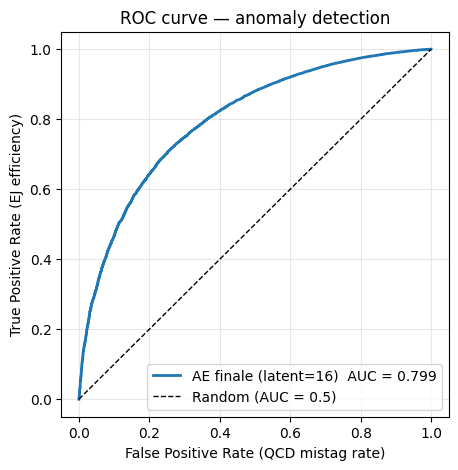

In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# VALUTAZIONE FINALE (eseguire UNA volta, con gli iperparametri GIA' scelti)
# ══════════════════════════════════════════════════════════════════════════════
# Questa e' la PRIMA e UNICA volta in cui il segnale e il test-QCD vengono usati.
# Durante tutto il tuning non sono mai stati osservati → nessun data leakage.
#
# PRIMA di eseguire: assicurati che LATENT_DIM / REPR / DROPOUT in Sezione 1
# siano quelli scelti dal tuning, e ri-esegui le celle di setup + dati + modello
# + training cosi' che `model` sia il modello finale addestrato su X_bkg_train.

scores_bkg_test = compute_anomaly_scores(model, X_bkg_test, device=DEVICE)
scores_sig_test = compute_anomaly_scores(model, X_sig,      device=DEVICE)

fpr, tpr, roc_auc = compute_roc(scores_bkg_test, scores_sig_test)

print('=' * 55)
print('VALUTAZIONE FINALE (test-QCD + segnale, mai visti nel tuning)')
print('=' * 55)
print(f'  Configurazione : latent={LATENT_DIM}, repr={REPR}, dropout={DROPOUT}')
print(f'  AUC finale     : {roc_auc:.4f}')
print(f'  N test-QCD     : {len(scores_bkg_test):,}')
print(f'  N segnale      : {len(scores_sig_test):,}')

plot_roc(fpr, tpr, roc_auc, label=f'AE finale (latent={LATENT_DIM})',
         save_path=os.path.join(PLOTS_DIR, 'ae_roc_finale.png'))
plt.show()

## Il nostro anomaly score: residuo di ricostruzione *standardizzato* (whitened)

**Una cosa importante: il modello non cambia, cambia solo come si *legge* l'errore.** L'autoencoder ha imparato a ricostruire il QCD; l'anomaly score e' la *ricetta* con cui trasformiamo l'errore di ricostruzione in un numero ("quanto e' anomalo questo jet").

**I modelli usano gia' score diversi per natura:**
- l'**NF** non usa l'MSE: il suo score e' una **log-verosimiglianza**;
- la **diffusion** usa l'**errore di denoising**;
- **AE/VAE** usano l'**errore di ricostruzione**.

Sono gia' tre ricette diverse, e va benissimo: **ogni modello ha il suo score naturale**, non esiste una regola "stessa formula per tutti". Quindi scegliere lo score migliore per l'AE e' del tutto legittimo.

**Quale score per l'AE? Il residuo standardizzato, scelto *a priori*.** L'MSE "ingenuo" media gli errori delle 43 feature **a peso uguale**, come se sbagliare su una feature precisa o su una rumorosa fosse la stessa cosa. Non lo e'. Misuriamo invece **quanti sigma e' fuori, feature per feature**: dividiamo l'errore di ogni feature per la sua **varianza di ricostruzione sul QCD** (stimata sul val, **senza mai toccare il segnale**) e poi mediamo. E' la **misura statisticamente corretta di anomalia** (una distanza in unita' della normale dispersione del QCD). La scegliamo **per principio**, non perche' "alza l'AUC sul segnale".

**Perche' il tuning resta su MSE (e non e' un'incoerenza).** Sono due domande diverse, entrambe solo-QCD:
- il **tuning** chiede *"quale modello impara meglio il QCD?"* -> si misura con la **qualita' di ricostruzione (MSE val)**;
- lo **score** chiede *"quanto e' anomalo questo jet?"* -> residuo standardizzato.

Allenare e selezionare il modello perche' ricostruisca bene il QCD, e poi misurare l'anomalia col residuo standardizzato, e' coerente: il modello fa il suo lavoro (ricostruire), lo score fa il suo (misurare la stranezza). *(Nota: lo score whitened non si potrebbe nemmeno usare come criterio di tuning, perche' dividendo l'errore per la sua stessa varianza sul QCD si auto-normalizza a ~1 per qualunque modello.)*

L'AUC del sommario qui sopra e' quella dell'MSE **ingenuo** (baseline); qui sotto applichiamo lo score che **adottiamo** (whitened) e lo confrontiamo col baseline.

_______________________________________________________________________________________________________________
Lo score base e' l'MSE medio di ricostruzione, che pesa **uguale** tutte le 43 feature: una feature intrinsecamente difficile da ricostruire (errore grande anche sul QCD) domina e copre il segnale. Lo score **whitened** divide l'errore di ogni feature per la sua **varianza di ricostruzione sul QCD** (stimata sul val, niente segnale): cosi' una feature conta solo se devia **piu' del solito**. E' una scelta di scoring, non un modello nuovo (stessi pesi). Qui sotto confrontiamo baseline vs whitened e adottiamo il migliore.

---> cambia solo come leggi l'errore !!

 I modelli usano già score diversi per natura.

  - l'NF non usa MSE per niente: il suo score è una log-verosimiglianza.
  - la diffusion usa l'errore di denoising.
  - AE/VAE usano l'errore di ricostruzione.

  Sono già tre ricette diverse — e va benissimo, perché ogni modello ha il suo score naturale. Non esiste una regola "stessa formula per tutti".
  Quindi usare whitened per AE/VAE e MSE per i GNN non è di per sé sbagliato: è semplicemente "ogni modello col suo score migliore". Il confronto
  resta onesto perché confronti "il meglio di ciascun modello".

### RICORDA: l'ho scelto perchè **il residuo standardizzato è la misura statisticamente corretta di anomalia**
_______________________________________________________________________________________________________________

In [ ]:
# === DESIGN CHOICE (whitened) ===
import numpy as np, torch
def _perdim_ae(X, bs=4096):
    model.eval(); o=[]
    with torch.no_grad():
        for st in range(0, len(X), bs):
            xb = torch.tensor(X[st:st+bs], dtype=torch.float32, device=DEVICE)
            o.append(((xb - model(xb))**2).cpu().numpy())
    return np.concatenate(o)
_var = _perdim_ae(X_bkg_val).mean(0) + 1e-6          # varianza ricostruzione QCD (val)
_ete, _esg = _perdim_ae(X_bkg_test), _perdim_ae(X_sig)
scores_bkg_base, scores_sig_base = _ete.mean(1), _esg.mean(1)            # baseline MSE
scores_bkg_official = (_ete/_var).mean(1); scores_sig_official = (_esg/_var).mean(1)  # whitened
_ab = compute_roc(scores_bkg_base, scores_sig_base)[2]
_aw = compute_roc(scores_bkg_official, scores_sig_official)[2]
print(f'AUC baseline (MSE): {_ab:.4f}  |  whitened: {_aw:.4f}  |  delta {_aw-_ab:+.4f}')
import matplotlib.pyplot as plt
for _s in ('base','official'):
    f,t,a = compute_roc(eval(f'scores_bkg_{_s}'), eval(f'scores_sig_{_s}'))
    plt.plot(f,t,label=f'{"baseline" if _s=="base" else "whitened"} (AUC {a:.3f})')
plt.plot([0,1],[0,1],':',c='gray'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('AE: baseline vs whitened'); plt.legend(); plt.show()

## Export per la Task 3 - salvataggio degli anomaly-score

Salva lo score **ufficiale** del modello (lo *whitened* dove adottato, altrimenti il baseline) e, per sicurezza, anche il **baseline** (`scores_*_base`), piu' gli indici `idx_sig`/`idx_bkg` per agganciare decay length e massa. Ricaricati dal notebook `08` per il confronto, senza riallenare.

In [ ]:
# === TASK3 EXPORT ===
# Salva gli anomaly-score (ufficiale + baseline) per il confronto in 08_evaluation_task3_locale.
import os, numpy as np
TASK3_DIR = "C:/Users/dfraj/OneDrive/Desktop/Master/Adv_ML/Progetto/ej_anomaly/notebooks_locali/task3_scores"
os.makedirs(TASK3_DIR, exist_ok=True)
# score ufficiale del modello (whitened se definito, altrimenti baseline del notebook)
sb = (scores_bkg_official if 'scores_bkg_official' in dir() else
      scores_bkg_test if 'scores_bkg_test' in dir() else scores_bkg)
ss = (scores_sig_official if 'scores_sig_official' in dir() else
      scores_sig_final if 'scores_sig_final' in dir() else scores_sig)
sb = np.asarray(sb, np.float32); ss = np.asarray(ss, np.float32)
idx_sig = np.arange(len(ss), dtype=np.int32)
_it = idx_test if 'idx_test' in dir() else (ite if 'ite' in dir() else None)
idx_bkg = np.asarray(_it, np.int32) if _it is not None else np.arange(len(sb), np.int32)
assert len(idx_bkg) == len(sb)
extra = {}
if 'scores_bkg_base' in dir() and 'scores_sig_base' in dir():
    extra['scores_bkg_base'] = np.asarray(scores_bkg_base, np.float32)
    extra['scores_sig_base'] = np.asarray(scores_sig_base, np.float32)
_path = os.path.join(TASK3_DIR, "ae.npz")
np.savez_compressed(_path, scores_bkg=sb, scores_sig=ss, idx_sig=idx_sig, idx_bkg=idx_bkg,
                    model_name="AE", **extra)
print(f"[Task 3] Salvato {_path} | bkg {len(sb):,} | sig {len(ss):,}" + (" (+baseline)" if extra else ""))
try:
    from sklearn.metrics import roc_auc_score
    y = np.r_[np.zeros(len(sb)), np.ones(len(ss))]
    print(f"         AUC ufficiale: {roc_auc_score(y, np.r_[sb, ss]):.4f}")
except Exception as e:
    print("         (AUC quick-check non disponibile)", e)